<a href="https://colab.research.google.com/github/gtsagkatakis/Data-Science-and-Applications-2026/blob/main/Multimodal_Universe_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

data = torch.load("multimodal_universe_processed.pt", map_location="cpu")
spectra = data["spectra"].float()   # [N, L]
Z = data["targets"].float()         # [N]

print(spectra.shape, Z.shape)

x = spectra.mean(dim=1)   # [N]

torch.Size([25, 3862]) torch.Size([25])


In [2]:
# Design matrix [x, 1]
X = torch.stack([x, torch.ones_like(x)], dim=1)   # [N, 2]

# Solve min ||X theta - Z||^2
theta = torch.linalg.lstsq(X, Z).solution         # [2]
a, b = theta[0].item(), theta[1].item()

print(f"Fitted line: Z ≈ {a:.6f} * x + {b:.6f}")

Fitted line: Z ≈ -0.026951 * x + 0.617894


RMSE: 0.5515


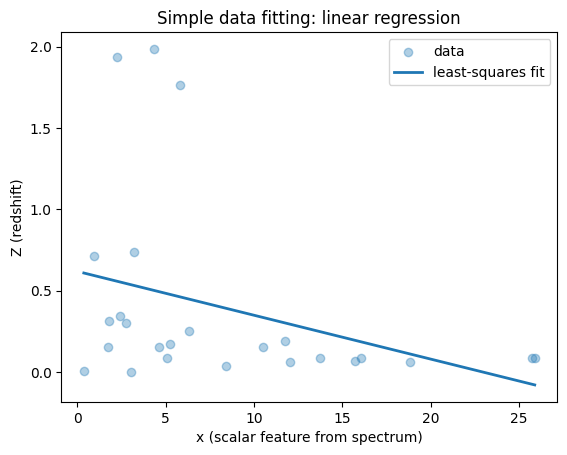

In [3]:
Z_pred = X @ theta
rmse = torch.sqrt(torch.mean((Z_pred - Z)**2)).item()

print(f"RMSE: {rmse:.4f}")

plt.figure()
plt.scatter(x.numpy(), Z.numpy(), alpha=0.35, label="data")
idx = torch.argsort(x)
plt.plot(x[idx].numpy(), Z_pred[idx].numpy(), linewidth=2, label="least-squares fit")
plt.xlabel("x (scalar feature from spectrum)")
plt.ylabel("Z (redshift)")
plt.title("Simple data fitting: linear regression")
plt.legend()
plt.show()

In [5]:
# ---- Gradient Descent Polynomial Fit (degree = 2) ----

# Standardize x for stability
eps = 1e-8
x_mean = x.mean()
x_std = x.std().clamp_min(eps)
x_n = (x - x_mean) / x_std

# Initialize parameters: Z ≈ a x^2 + b x + c
a = torch.tensor(0.0)
b = torch.tensor(0.0)
c = torch.tensor(0.0)

lr = 1e-2
epochs = 2000

loss_hist = []

for t in range(epochs):

    # Forward
    Z_pred = a * x_n**2 + b * x_n + c
    err = Z_pred - Z
    loss = (err**2).mean()

    # Manual gradients of MSE
    grad_a = (2.0 * err * (x_n**2)).mean()
    grad_b = (2.0 * err * x_n).mean()
    grad_c = (2.0 * err).mean()

    # Update
    a -= lr * grad_a
    b -= lr * grad_b
    c -= lr * grad_c

    loss_hist.append(loss.item())

print(f"Fitted quadratic:")
print(f"Z ≈ {a.item():.6f} x_n² + {b.item():.6f} x_n + {c.item():.6f}")

rmse_poly = torch.sqrt(torch.mean((Z_pred - Z)**2)).item()
print(f"Quadratic GD RMSE: {rmse_poly:.4f}")

Fitted quadratic:
Z ≈ 0.043393 x_n² + -0.245809 x_n + 0.351405
Quadratic GD RMSE: 0.5498


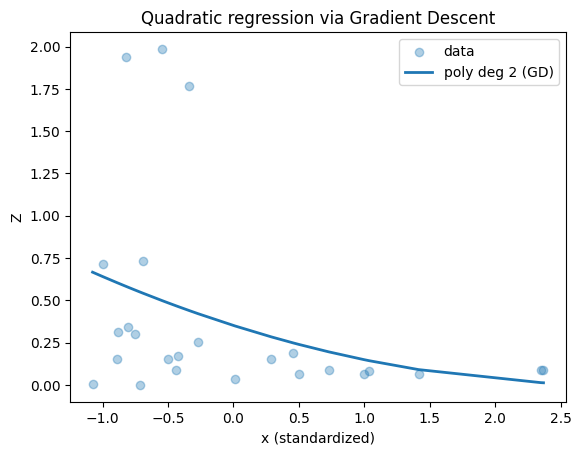

In [6]:
plt.figure()
plt.scatter(x_n.numpy(), Z.numpy(), alpha=0.35, label="data")

idx = torch.argsort(x_n)
plt.plot(x_n[idx].numpy(),
         (a * x_n[idx]**2 + b * x_n[idx] + c).detach().numpy(),
         linewidth=2,
         label="poly deg 2 (GD)")

plt.xlabel("x (standardized)")
plt.ylabel("Z")
plt.title("Quadratic regression via Gradient Descent")
plt.legend()
plt.show()